In [1]:
# statistical inference: Estimation and confidence intervals

# Statistical inference is the process of drawing conclusions about a population based on a sample of data.

# population: entire group of interest
# sample: subset of population

# properties of the population:
    # -goal: estimate unknown parameters of population and assess the reliability of the estimate
    # -parameters: mean, variance, standard deviation, etc


In [2]:
# Estimation: 
    # -Point Estimation: it is a single value that estimates the population parameter
    #   -eg: sample mean, sample standard deviation
    # -Interval Estimation: it is a range of values that estimates the population parameter is likely to lie
    #   -eg: confidence interval
    #   -confidence inteval(CI): CI=(sample statistic) +/- margin of error
    # CI=x_bar +/- z*(s/sqrt(n))
    # where x_bar is sample mean, z is z-score corresponding to desired confidence level, s is sample standard deviation, n is sample size

#z*(s/sqrt(n)) is margin of error


# Construction of confidence interval:
    # -For means
    #   -when the population standard deviation is known: z-distribution CI=x_bar +/- z*(s/sqrt(n))
    #   -when the population standard deviation is unknown: t-distribution CI=x_bar +/- t*(s/sqrt(n)), use the t-distribution for samples(n<30)
        # -use the t-distribution when the population standard deviation is unknown and the sample size is small(n<30)
     
    # -For proportions: CI=p_cap +/- z*(sqrt(p_cap*(1-p_cap)/n))
    # where p_cap is sample proportion, z is z-score corresponding to desired confidence level, n is sample size


sample mean: 14.142857142857142
sample standard deviation: 1.9518001458970662
margin of error: 1.8051140664994405
confidence interval: (np.float64(12.337743076357702), np.float64(15.947971209356583))


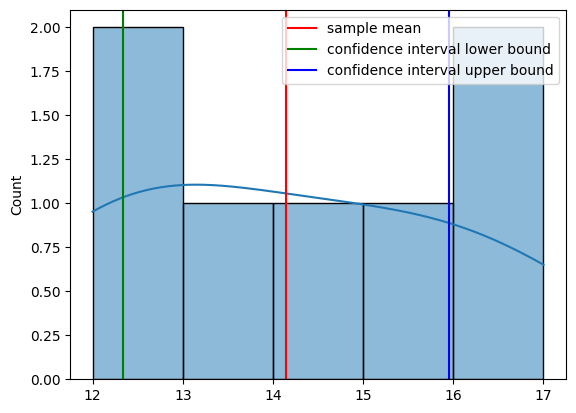

In [10]:
# example for confidence interval

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t
import seaborn as sns

# sample data
data=[12,12,14,15,13,16,17]

# calculate Mean and standard deviation
mean=np.mean(data)
sd=np.std(data,ddof=1) # ddof=1 for sample standard deviation

#95%  calculate confidence interval(using t-distribution)
n=len(data)
t_value=t.ppf(0.975,df=n-1)
margin_of_error=t_value*(sd/np.sqrt(n))
confidence_interval=(mean-margin_of_error,mean+margin_of_error)

print("sample mean:",mean)
print("sample standard deviation:",sd)
print("margin of error:",margin_of_error)
print("confidence interval:",confidence_interval)

# plotting
sns.histplot(data,bins=5,kde=True)
plt.axvline(x=mean,color='r',label='sample mean')
plt.axvline(x=confidence_interval[0],color='green',label='confidence interval lower bound')
plt.axvline(x=confidence_interval[1],color='blue',label='confidence interval upper bound')
plt.legend()
plt.show()

In [11]:
# execrise


(np.float64(47.18155741526743), np.float64(50.74151223685072))
Sample mean: 48.96153482605907
Sample standard deviation: 9.081684280078008
Margin of error: 1.7799774107916466
95% confidence interval: (np.float64(47.18155741526743), np.float64(50.74151223685072))


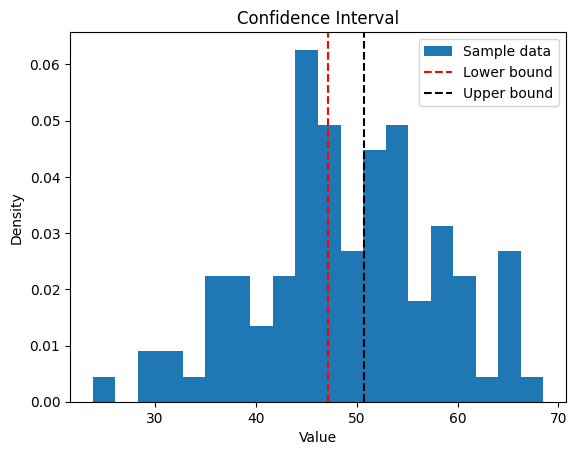

In [21]:
# 1.Calculate the confidence interval for a sample of data

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import pandas as pd

# Generate random sample data
np.random.seed(42)
sample_data = np.random.normal(loc=50, scale=10, size=100)

# Calculate confidence interval using z-distribution
ci = norm.interval(0.95, loc=np.mean(sample_data), scale=np.std(sample_data, ddof=1)/np.sqrt(len(sample_data)))
print(ci)

# sample statistics
sample_mean = np.mean(sample_data)
sample_std = np.std(sample_data, ddof=1)
n = len(sample_data)

# Calculate 95% of confidence interval
z_score = norm.ppf(0.975)
margin_of_error = z_score * (sample_std / np.sqrt(n))
confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)

print("Sample mean:", sample_mean)
print("Sample standard deviation:", sample_std)
print("Margin of error:", margin_of_error)
print("95% confidence interval:", confidence_interval)

# plot the data vs Confidence interval
plt.hist(sample_data, bins=20, density=True, label='Sample data')
plt.axvline(confidence_interval[0], color='r', linestyle='--', label='Lower bound')
plt.axvline(confidence_interval[1], color='black', linestyle='--', label='Upper bound')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Confidence Interval')
plt.legend()
plt.show()


In [31]:
# 2.onduct sampling and create a report

import pandas as pd
from scipy.stats import norm
import numpy as np


url='https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'

# load the iris dataset
iris=pd.read_csv(url)

# Sampling
sample=iris['sepal_length'].sample(n=30, random_state=42)

# calculate the sample mean and standard deviation
sample_mean=sample.mean()
sample_std=sample.std()
n=len(sample)

# calculate the confidence interval
z_value=norm.ppf(0.975)
confidence_interval=(sample_mean-z_value*(sample_std/np.sqrt(n)),sample_mean+z_value*(sample_std/np.sqrt(n)))

print("sample mean:",sample_mean)
print("sample standard deviation:",sample_std)
print("confidence interval:",confidence_interval)


sample mean: 5.98
sample standard deviation: 0.8450260146985071
confidence interval: (np.float64(5.677616880642557), np.float64(6.282383119357444))


sample mean: 5.843333333333334
sample standard deviation: 0.828066127977863
confidence interval: (np.float64(5.7774123000114255), np.float64(5.909254366655242))


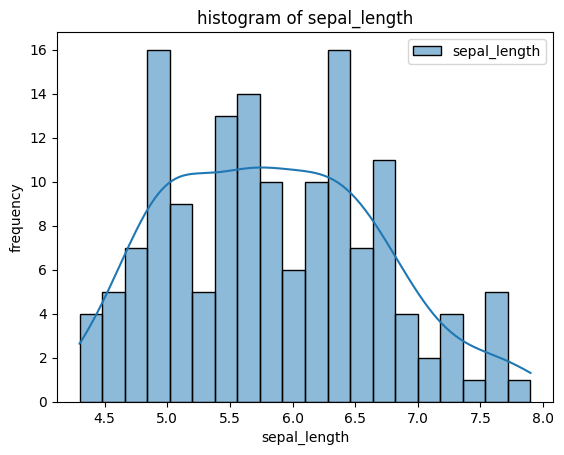

In [38]:
import pandas as pd
from scipy.stats import norm
import numpy as np


url='https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'

# load the iris dataset
iris=pd.read_csv(url)

# calculate the sample mean and standard deviation
sample_mean=iris['sepal_length'].mean()
sample_std=iris['sepal_length'].std()

# calculate the confidence interval
confidence_interval=(sample_mean-0.975*(sample_std/np.sqrt(len(iris))),sample_mean+0.975*(sample_std/np.sqrt(len(iris))))

print("sample mean:",sample_mean)
print("sample standard deviation:",sample_std)
print("confidence interval:",confidence_interval)

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(iris['sepal_length'],bins=20,kde=True, label='sepal_length')
# sns.lineplot(x=np.linspace(iris['sepal_length'].min(),iris['sepal_length'].max(),100),y=norm.pdf(np.linspace(iris['sepal_length'].min(),iris['sepal_length'].max(),100),sample_mean,sample_std),label='normal distribution')
plt.xlabel('sepal_length')
plt.ylabel('frequency')
plt.title('histogram of sepal_length')
plt.legend()
plt.show()